# Process sincFold training

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

METRICS_PATH = Path("../results/metrics_all.csv")
metrics_all = pd.read_csv(METRICS_PATH)
display(metrics_all.head(1))
print(f"models: {metrics_all.model.unique()}")
print(f"strategies: {metrics_all.strategy.unique()}")

,model,strategy,fam,epoch,train_loss,valid_loss,valid_f1,test_f1
0,sincFold,sortS400,tRNA,0.0,0.0487,0.0386,0.4232,NaN


models: <StringArray>
['sincFold', 'eFold', 'REDFold', 'UFold', 'RiNALMo-ResNet']
Length: 5, dtype: str
strategies: <StringArray>
['sortS400', 'sortS200', 'sortS100', 'clusS400', 'clusS200', 'clusS100',
 'randS400', 'randS200', 'randS100',     'full']
Length: 10, dtype: str


# SETUP PLOT

In [12]:
def smooth_curve(y, window=5):
    return y.rolling(window=window, center=True, min_periods=1).mean()

def plot_loss_and_f1_across_datasets(
    metrics, 
    strategies, 
    fams,
    title="Train/Valid Loss and Valid/Test F1 by family", 
    figsize=(5, 4),  
    save=False
): 
    plt.rcParams.update({'font.size': 14})
    n_fams = len(fams)
    rows, cols = 2, n_fams

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(figsize[0] * cols, figsize[1] * rows),
        constrained_layout=True,
        sharex=True,
        sharey="row"
    ) 
    base_colors = ['gray', 'green', 'purple', 'orange', 'brown', 'blue']
 
    for col, fam in enumerate(fams):


        # row 0: Loss
        ax_loss = axes[0, col]
        for i, strategy in enumerate(strategies):
            df = metrics.query("strategy == @strategy and fam == @fam")
            color = base_colors[i % len(base_colors)]
 
            ax_loss.plot(df['epoch'],
                        smooth_curve(df['train_loss']),
                        label=strategy, 
                        color=color,
                        linewidth=1)
            
            ax_loss.plot(df['epoch'], 
                        smooth_curve(df['valid_loss']),
                        color=color,
                        linewidth=2,
                        linestyle="--")
           

        ax_loss.set_title(fam, fontsize=20, fontweight='bold')
        ax_loss.set_xlim(0, 25)
        ax_loss.grid(False)


        # row 1: F1 score

        ax_f1 = axes[1, col]
        for i, strategy in enumerate(strategies):
            df = metrics.query("strategy == @strategy and fam == @fam")
            color = base_colors[i % len(base_colors)]
            
            ax_f1.plot(df['epoch'],
                        smooth_curve(df['valid_f1']),
                        color=color,
                        linewidth=2,
                        linestyle="--",
                        label=f"F1 ({strategy})")
            
 
            # test f1 points
            test_rows = df['test_f1'].notna()
            ax_f1.scatter(
                df.loc[test_rows, 'epoch'],
                df.loc[test_rows, 'test_f1'],
                color=color, s=50,
                marker='o' if i == 0 else 'x', # different marker for full dataset
                label=None
            )

        ax_f1.set_ylim(0, 1)
        ax_f1.set_xlim(0, 25)
        ax_f1.set_xlabel("Epoch", fontsize=16)
        ax_f1.grid(False)

        if col == 0:
            ax_loss.set_ylabel("Loss", fontsize=18)
            ax_f1.set_ylabel("F1 Score", fontsize=18)

        ax_f1.set_xlabel("Epoch")
 
    handles, labels = axes[0, -1].get_legend_handles_labels()
    axes[0, -1].legend(handles, labels, loc="upper right") #, ncol=len(dataset_names)

    fig.suptitle(title, fontsize=24)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if save:
        fig.savefig("loss_f1_comparison.pdf", dpi=300)

    plt.show()


In [13]:
fams = ['5s', 'tRNA',  'tmRNA',   'RNaseP','srp',  'telomerase', 'grp1', '23s', '16s', ]
fams_selected = ['tRNA', 'srp', 'telomerase',  'grp1', '23s']
fams_others = ['5s', 'tmRNA', 'RNaseP', '16s',]

 
dataset_sortS = ["full", "sortS100", "sortS200", "sortS400"] 
dataset_clusS = ["full", "clusS100", "clusS200", "clusS400"]
dataset_thr100 = ["full", "sortS100", "clusS100", "randS100"]


# sincFold

/tmp/ipykernel_2221342/1924985324.py:92: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])


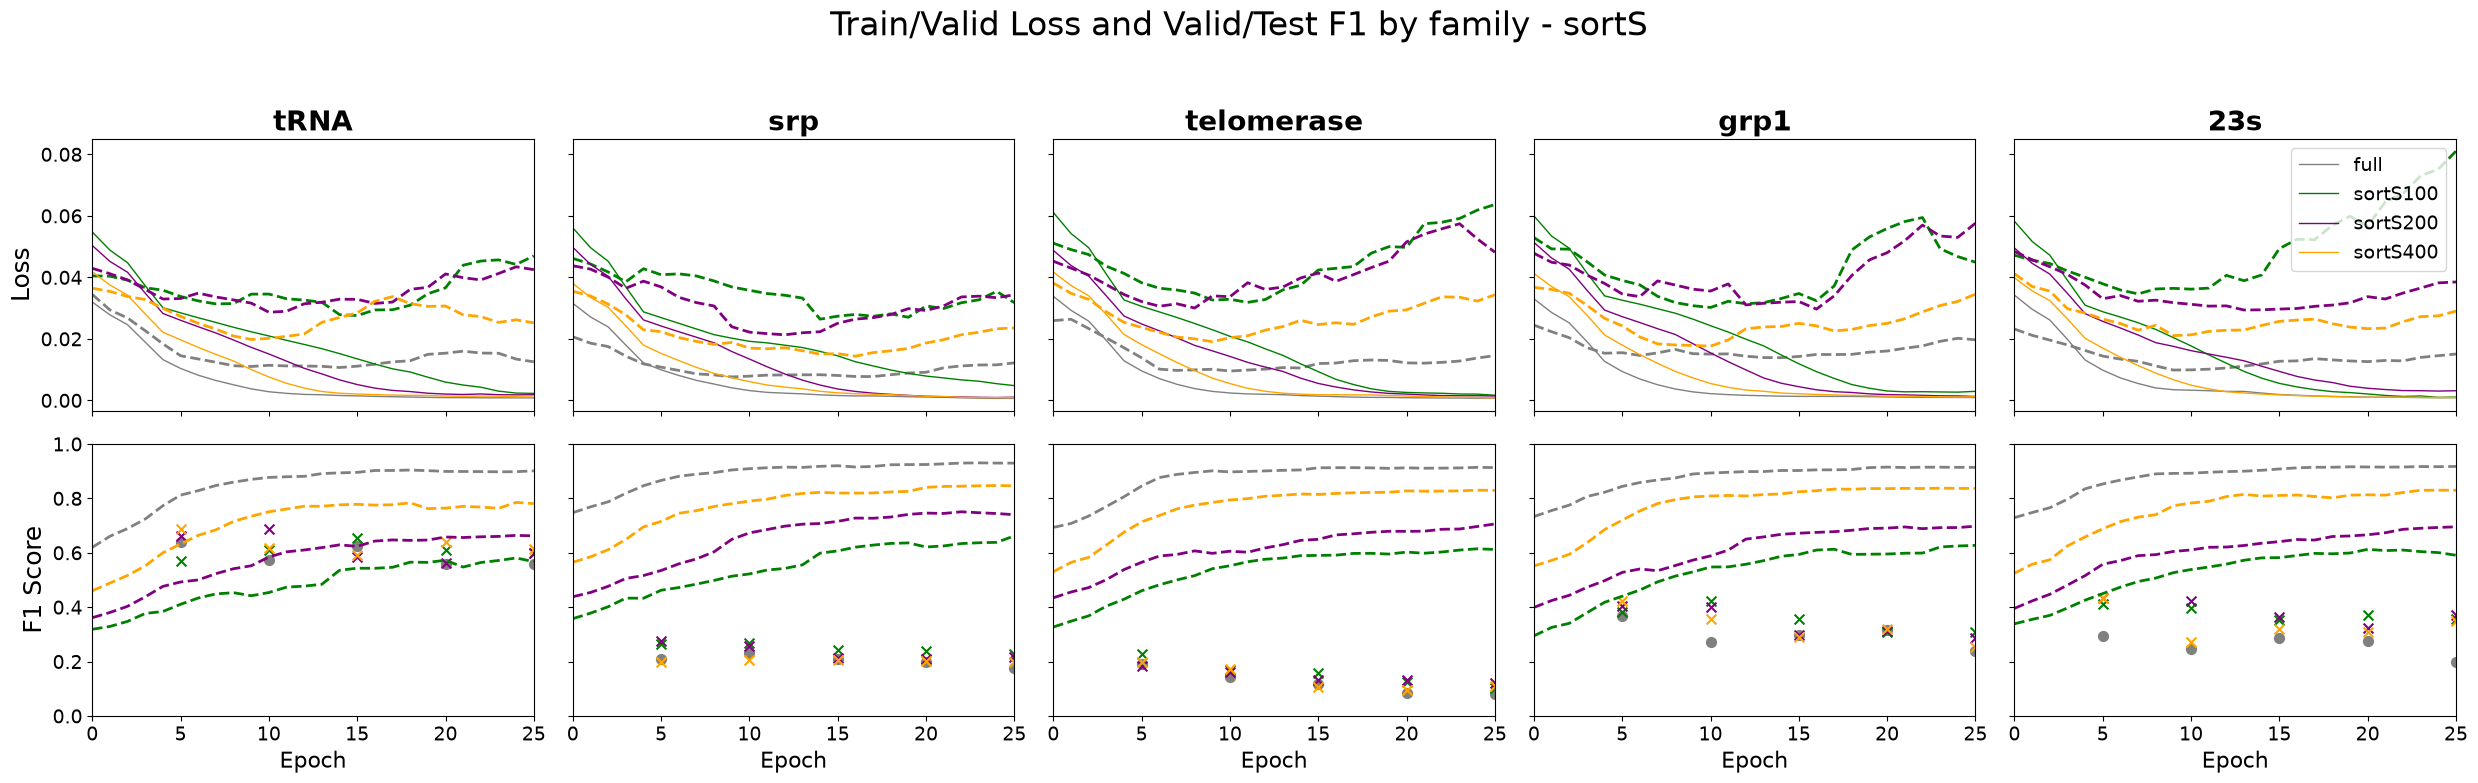

/tmp/ipykernel_2221342/1924985324.py:92: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])


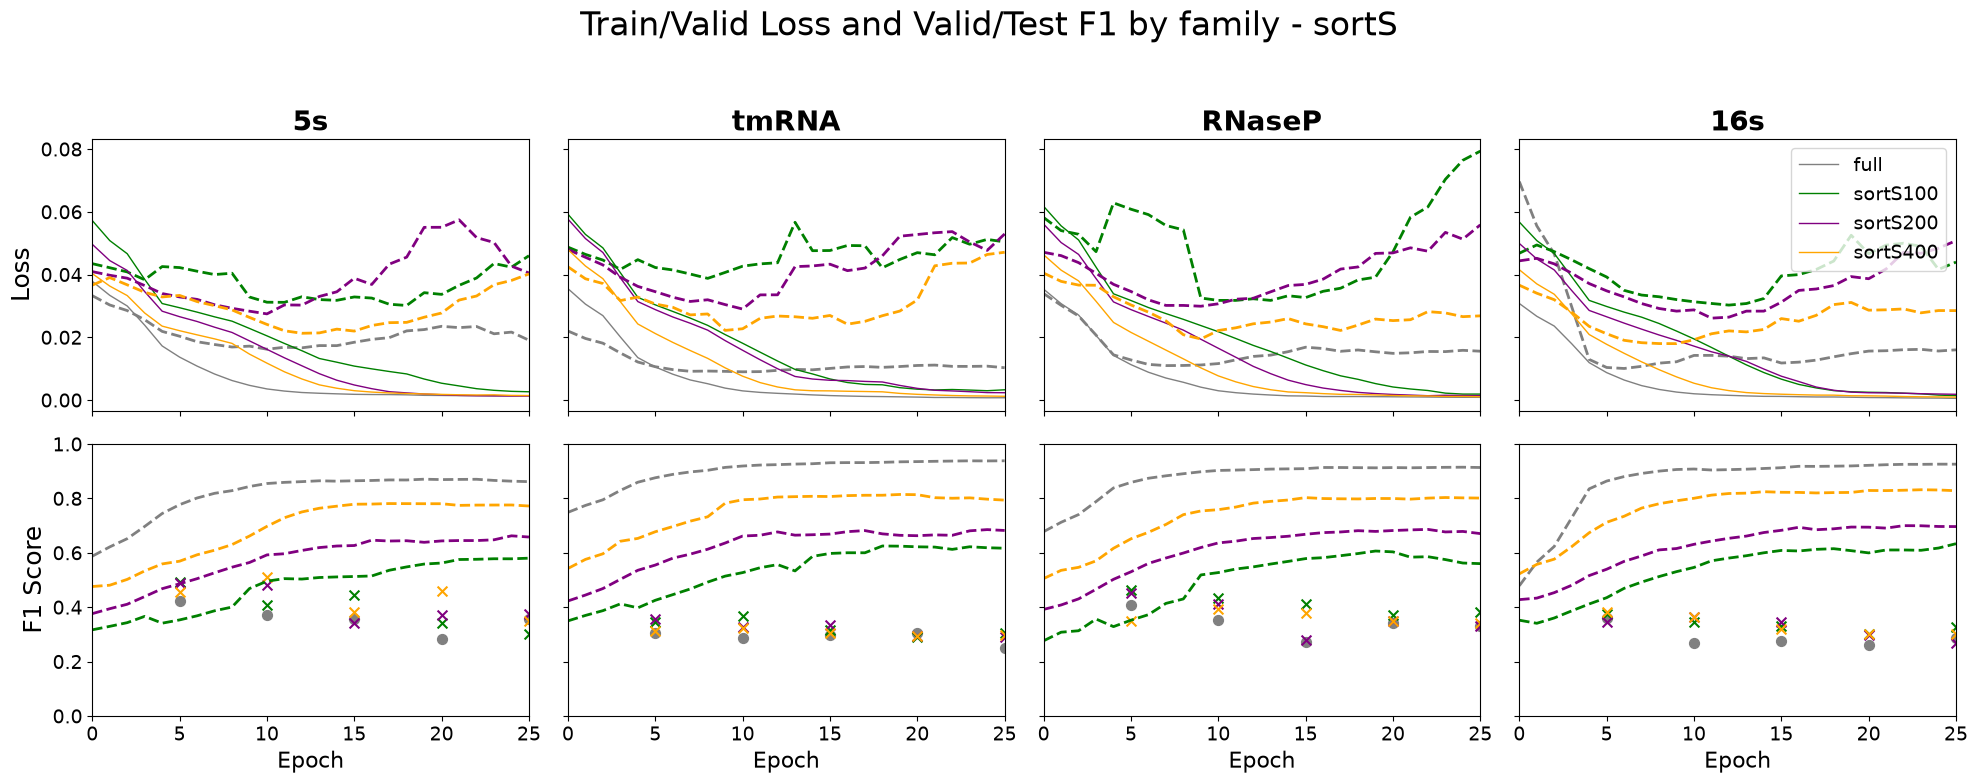

In [14]:
metrics = metrics_all.query("model == 'sincFold'").copy()
plot_loss_and_f1_across_datasets(
    metrics=metrics,
    strategies=dataset_sortS,
    fams=fams_selected,
    title="Train/Valid Loss and Valid/Test F1 by family - sortS",
)

plot_loss_and_f1_across_datasets(
    metrics=metrics,
    strategies=dataset_sortS,
    fams=fams_others,
    title="Train/Valid Loss and Valid/Test F1 by family - sortS",
)

/tmp/ipykernel_2221342/1924985324.py:92: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])


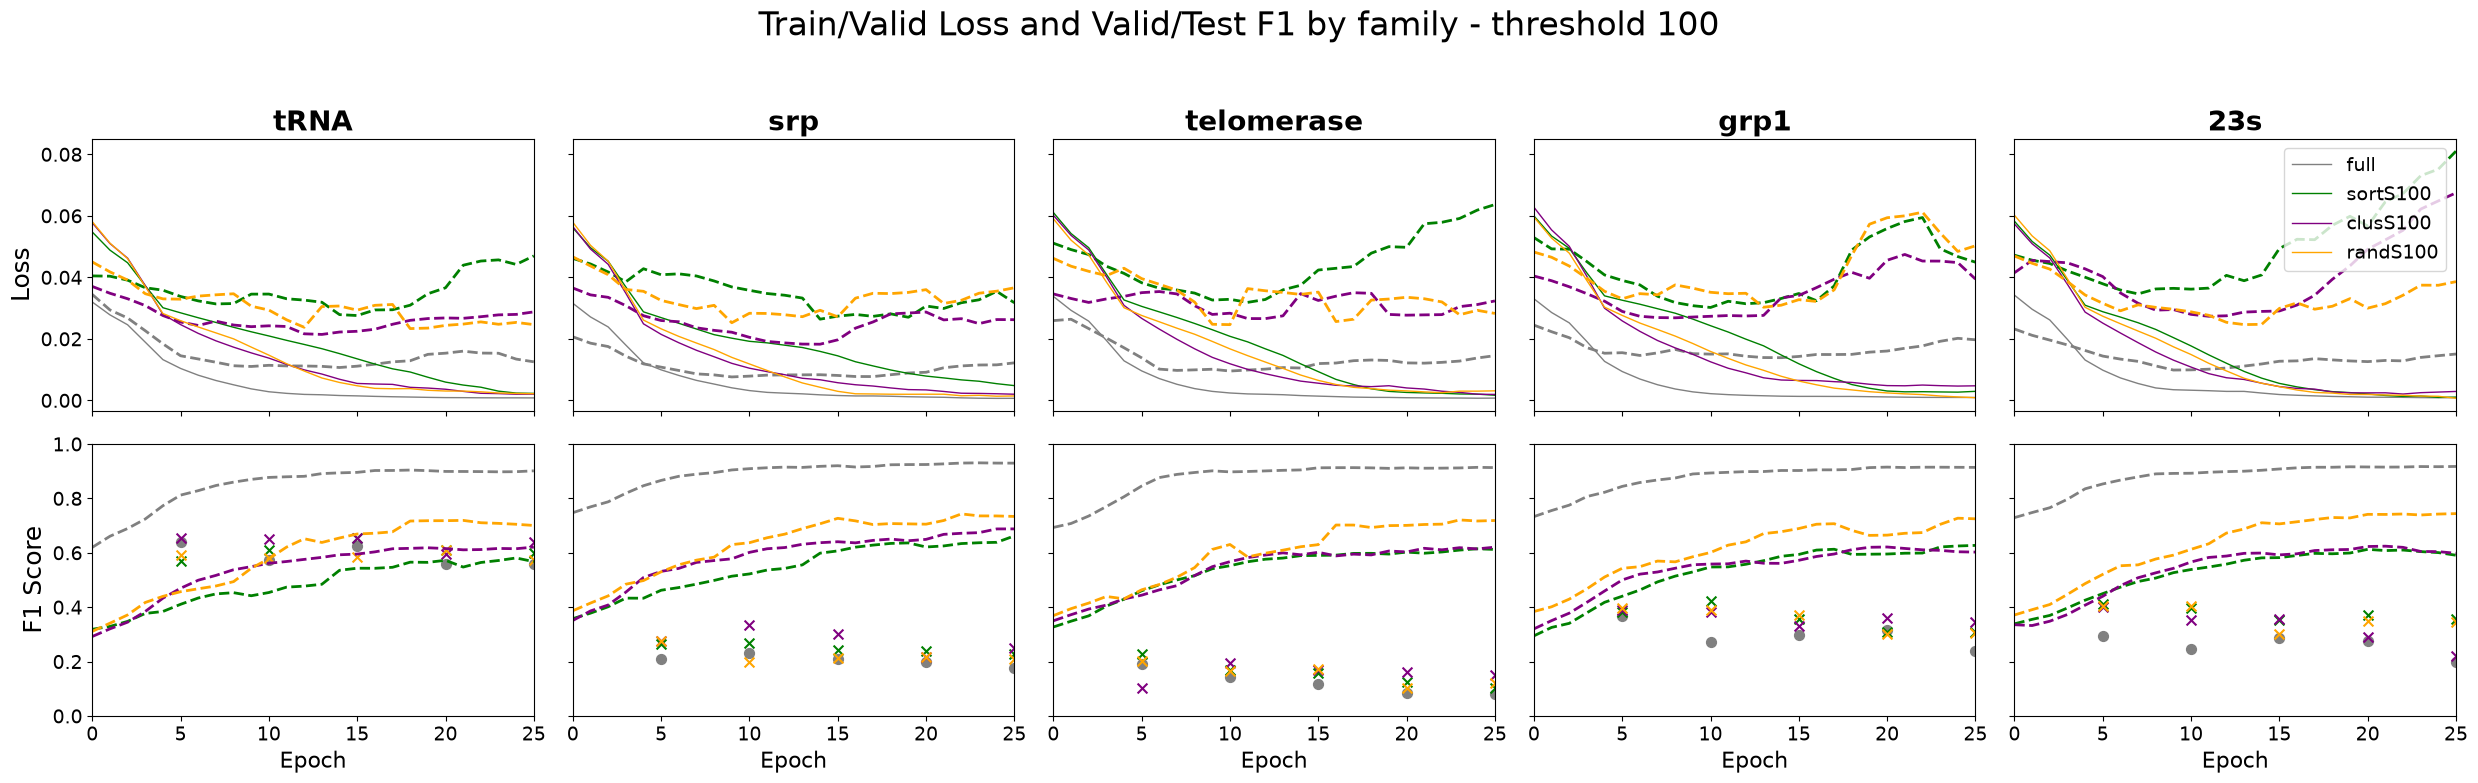

/tmp/ipykernel_2221342/1924985324.py:92: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.95])


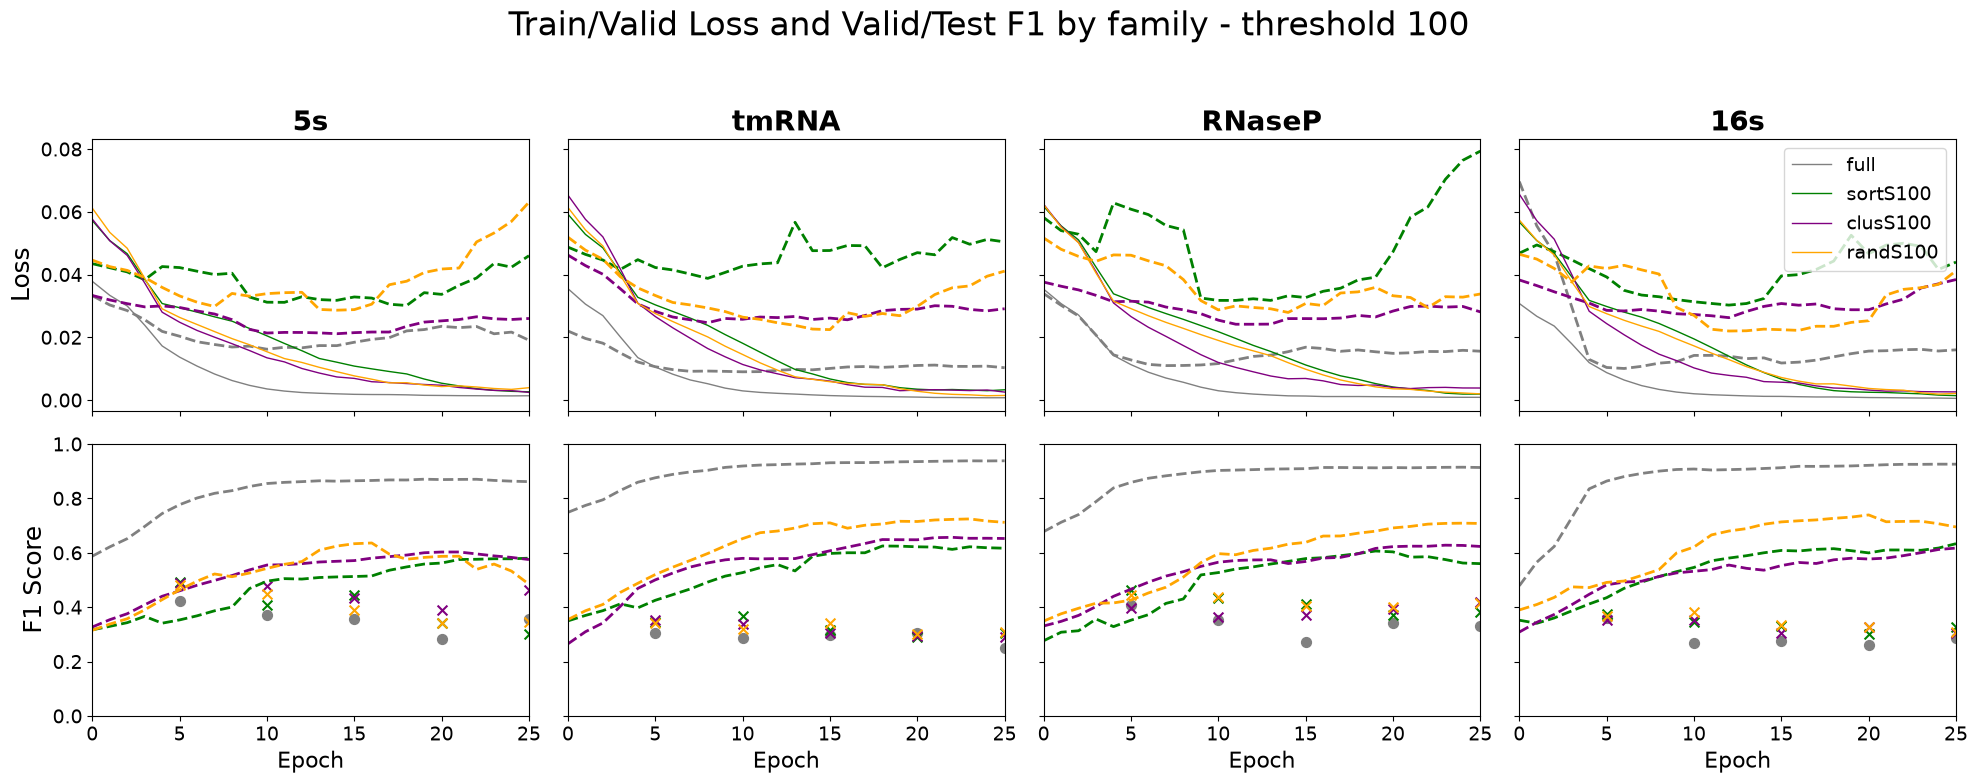

In [15]:
plot_loss_and_f1_across_datasets(
    metrics=metrics,
    strategies=dataset_thr100,
    fams=fams_selected,
    title="Train/Valid Loss and Valid/Test F1 by family - threshold 100",
)

plot_loss_and_f1_across_datasets(
    metrics=metrics,
    strategies=dataset_thr100,
    fams=fams_others,    
    title="Train/Valid Loss and Valid/Test F1 by family - threshold 100",

)

# F1 by method / fam

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

FIXED_EPOCH = 15
metrics_fix = metrics[metrics["epoch"] == FIXED_EPOCH] 

# best val id
valid_idx = metrics.groupby(["fam", "strategy"])["valid_loss"].idxmin()
# ceil / 5
valid_idx = valid_idx.apply(lambda idx: idx + (4 - (metrics.loc[idx, "epoch"] - 1) % 5))  # ceil to next multiple of 5
#filter best metrics
metrics_best = metrics.loc[valid_idx]

In [17]:
 
import matplotlib.pyplot as plt
import seaborn as sns

pivot_best = metrics_best.pivot(index="strategy", columns="fam",  values="test_f1") 

methods_order = [
    "randS100",
    "randS200",
    "randS400",
    "sortS100",
    "sortS200",
    "sortS400",
    "clusS100",
    "clusS200",
    "clusS400",
    "full",
    ]
families_order = ['5s', 'tRNA',  'tmRNA',   'RNaseP','srp',  'telomerase', 'grp1', '23s', '16s', ]

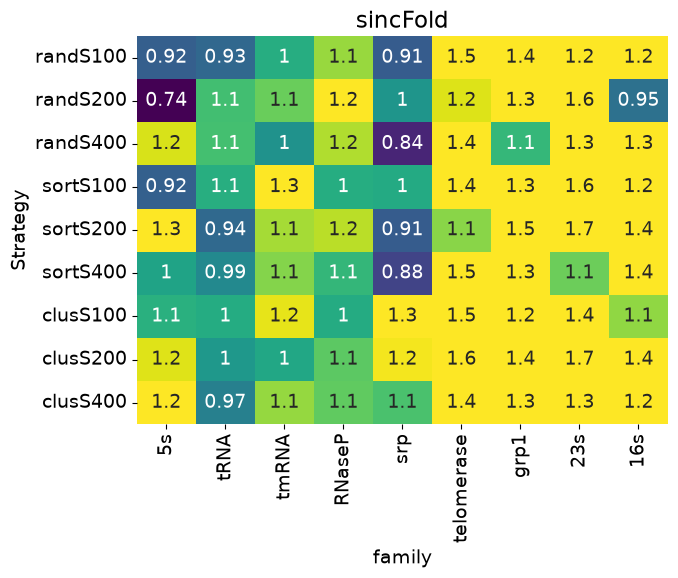

In [ ]:
df_best = pivot_best.loc[methods_order[:-1], families_order] / pivot_best.loc["full", families_order]
fig, ax = plt.subplots(1, 1, figsize=(7, 6), sharey=True)
sns.heatmap(df_best, annot=True, cmap="viridis", cbar=False,ax=ax, vmin=0.8, vmax=1.2)
ax.set_title("sincFold")
ax.set_xlabel("family")
ax.set_ylabel("Strategy") 
plt.tight_layout()
plt.show()